In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_gene_tcga = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/TCGA_TPM_expanded.parquet')
df_gene_gtex = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_TPM_expanded.parquet')

In [3]:
df_gene_gtex=df_gene_gtex.T
df_gene_gtex

,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
SMTSD,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0.054246,0.000000,0.070871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.161340,0.000000,0.000000,0.064947,0.000000,0.051758,0.076128,0.088275,0.000000
ENSG00000227232,0.583530,0.965060,1.409238,0.455305,1.018168,0.835866,2.062372,2.433939,2.239464,2.145971,...,0.784634,1.564634,3.761469,0.421292,0.677470,2.241035,0.134975,1.017442,0.733769,0.433996
ENSG00000278267,0.000000,0.000000,0.000000,0.000000,1.733982,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.596948,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032564,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.042791,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.028351,0.000000,0.000000,0.000000,0.000000,0.000000,0.032736,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.032812,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,20230.621466,6822.990804,8461.312447,6569.553657,11437.569748,4728.692022,5338.248368,6573.868115,8074.852964,4348.826457,...,448.484928,3455.236741,2352.215529,3657.985159,3957.733880,6003.838017,373.195157,5188.230674,3355.882194,239.161523
ENSG00000210194,61.374015,10.002468,29.002872,13.075735,34.177036,5.697867,18.309490,47.642225,21.416057,20.388632,...,0.000000,7.767719,12.590427,17.364560,12.507426,30.647329,1.245954,14.660663,12.749943,0.000000
ENSG00000198727,56980.806652,57466.961175,49799.986841,57421.014610,43694.674283,54814.492594,34208.016806,33185.252571,38692.089527,46222.933631,...,2892.221852,9008.778838,9921.217903,5635.842240,12262.188795,9766.475114,1517.109635,12773.375829,6640.759311,1075.384117


In [4]:
shared_genes = set(df_gene_gtex.index) & set(df_gene_tcga.index)

In [5]:
shared_genes = sorted(list(shared_genes))
len(shared_genes)

56957

In [21]:
df_gene_gtex_shared = df_gene_gtex.loc[shared_genes].sort_index()
df_gene_tcga_shared = df_gene_tcga.loc[shared_genes].sort_index()

In [27]:
df_gene_gtex_shared.shape

(56957, 19616)

In [28]:
assert all(df_gene_gtex_shared.index == df_gene_tcga_shared.index)

In [30]:
df_merged = pd.concat([df_gene_gtex_shared, df_gene_tcga_shared], axis=1)
df_merged

,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,f6c215ea-5381-4521-bb61-be8e97,f9d6fb1b-988e-4d28-9272-cc672f,faadb553-9437-42cb-b469-498d67,fbb41c94-aabd-49cc-90b2-882c3e,fc0aa1e4-c1d8-43ed-a5cd-038f61,fd4edc52-09ef-4b01-be7c-f23f05,fe4b3b1c-9f7f-4109-8a76-ca1d6f,fe591474-99d7-44d3-be73-c3b8ed,fe83e13f-9754-403b-8f74-d6caf8,ffc76bfb-61f6-4492-a782-c23321
ENSG00000000003,24.483706,20.911614,19.497767,17.091550,18.257684,22.377526,24.959735,22.870446,31.910213,21.520535,...,30.585676,35.348625,37.658157,28.782489,8.978696,10.949873,212.498873,11.932543,65.229204,15.971903
ENSG00000000005,6.912864,7.426833,12.968614,0.948350,68.064882,6.710334,12.168769,13.119936,11.317563,6.706862,...,1.552510,0.388546,0.158933,0.024295,0.028189,0.189491,2.676623,0.000000,0.299973,0.882351
ENSG00000000419,4.937467,4.826987,6.300498,3.478406,7.898260,4.942264,7.589236,7.210019,5.671506,7.482194,...,13.056098,5.352934,10.574750,9.114176,8.623198,7.915481,26.815117,18.326418,30.944793,30.847607
ENSG00000000457,2.261751,1.972197,1.951711,0.842236,2.391279,1.274841,1.870172,3.239976,1.864570,2.545027,...,3.062372,1.643973,5.401579,2.219777,3.453437,1.725366,2.105817,3.562212,2.819844,5.628781
ENSG00000000460,0.177457,0.177047,0.138742,0.070957,0.190778,0.102294,0.149611,0.296607,0.199455,0.241967,...,0.579031,0.245968,0.779936,0.266608,0.425892,0.204041,0.387967,0.411022,0.712466,0.503083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288659,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000288662,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002317,0.000000,0.000000
ENSG00000288667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.010304,0.000000,0.000000,0.017567,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000288670,5.004413,3.807052,4.687206,1.928601,5.920957,3.822180,3.670088,6.240184,5.517409,5.611304,...,25.912900,4.764338,20.729351,16.396326,6.038698,6.418258,5.565303,5.828151,8.264787,10.631132


In [31]:
del df_gene_gtex, df_gene_tcga, df_gene_tcga_shared, df_gene_gtex_shared
gc.collect()

3666

# select only shared with single cell data mRNAs

In [6]:
path = "/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/TPM_full.csv"
ss_data = pd.read_csv(path, index_col=0)
ss_cols = set(ss_data.index)

In [7]:
shared_genes_full = sorted(list(set(shared_genes) & ss_cols))

In [10]:
len(shared_genes_full)


17392

In [12]:
with open('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/shared_features.txt', 'w') as f:
    for row in shared_genes_full:
        f.write(f"{row}\n")

In [43]:
df_merged_sub = df_merged.loc[shared_genes_full].sort_index()

In [44]:
df_merged_sub.shape

(17392, 35580)

In [45]:
df_merged_sub.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_sub_v2.parquet')

# FEATURE SELECTION

In [46]:
del df_merged, ss_data
gc.collect()

7703

In [47]:
df_merged_sub.head(5)

,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,f6c215ea-5381-4521-bb61-be8e97,f9d6fb1b-988e-4d28-9272-cc672f,faadb553-9437-42cb-b469-498d67,fbb41c94-aabd-49cc-90b2-882c3e,fc0aa1e4-c1d8-43ed-a5cd-038f61,fd4edc52-09ef-4b01-be7c-f23f05,fe4b3b1c-9f7f-4109-8a76-ca1d6f,fe591474-99d7-44d3-be73-c3b8ed,fe83e13f-9754-403b-8f74-d6caf8,ffc76bfb-61f6-4492-a782-c23321
ENSG00000000003,24.483706,20.911614,19.497767,17.091550,18.257684,22.377526,24.959735,22.870446,31.910213,21.520535,...,30.585676,35.348625,37.658157,28.782489,8.978696,10.949873,212.498873,11.932543,65.229204,15.971903
ENSG00000000005,6.912864,7.426833,12.968614,0.948350,68.064882,6.710334,12.168769,13.119936,11.317563,6.706862,...,1.552510,0.388546,0.158933,0.024295,0.028189,0.189491,2.676623,0.000000,0.299973,0.882351
ENSG00000000419,4.937467,4.826987,6.300498,3.478406,7.898260,4.942264,7.589236,7.210019,5.671506,7.482194,...,13.056098,5.352934,10.574750,9.114176,8.623198,7.915481,26.815117,18.326418,30.944793,30.847607
ENSG00000000457,2.261751,1.972197,1.951711,0.842236,2.391279,1.274841,1.870172,3.239976,1.864570,2.545027,...,3.062372,1.643973,5.401579,2.219777,3.453437,1.725366,2.105817,3.562212,2.819844,5.628781
ENSG00000000460,0.177457,0.177047,0.138742,0.070957,0.190778,0.102294,0.149611,0.296607,0.199455,0.241967,...,0.579031,0.245968,0.779936,0.266608,0.425892,0.204041,0.387967,0.411022,0.712466,0.503083


In [48]:
vars = df_merged_sub.var(axis=1)

In [11]:
vars.sort_values() 

gene_id
ENSG00000283958    0.000000e+00
ENSG00000201588    0.000000e+00
ENSG00000278641    0.000000e+00
ENSG00000281652    0.000000e+00
ENSG00000280757    0.000000e+00
                       ...     
ENSG00000198804    9.579280e+08
ENSG00000211592    9.640493e+08
ENSG00000188536    1.061611e+09
ENSG00000244734    1.154812e+09
ENSG00000276168    1.217513e+10
Length: 56999, dtype: float64

Plot saved to: /mnt/jack-5/amismailov/miRNA_study/figures/log_varience_mrna_merged.jpg


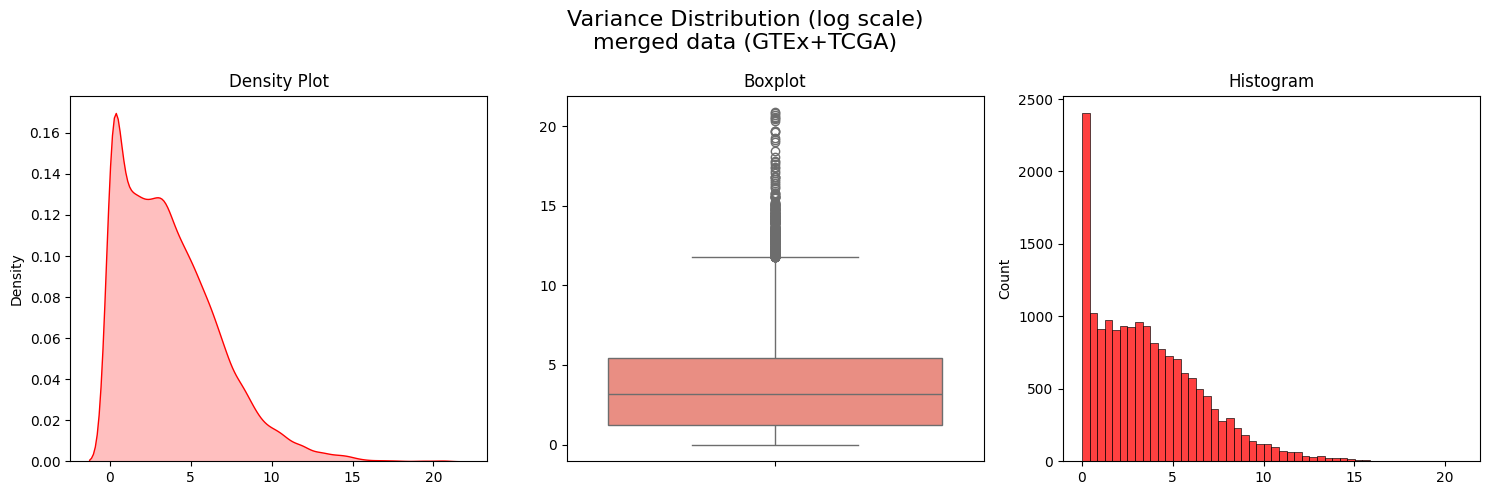

In [55]:
import os
def plot_var(vars, save_path=None):
    """
    vars: массив значений дисперсии
    save_path: путь к файлу (например, 'plots/variance_dist.pdf')
    """
    vars_log = np.log(vars + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Density
    sns.kdeplot(data=vars_log, fill=True, color='red', ax=axes[0])
    axes[0].set_title('Density Plot')
    
    # 2. Boxplot
    sns.boxplot(data=vars_log, color='salmon', ax=axes[1])
    axes[1].set_title('Boxplot')
    
    # 3. Hist
    sns.histplot(data=vars_log, bins=50, color='red', ax=axes[2])
    axes[2].set_title('Histogram')
    
    fig.suptitle("Variance Distribution (log scale)\nmerged data (GTEx+TCGA)", fontsize=16)
    plt.tight_layout()
    
    # Сохранение, если путь указан
    if save_path:
        # Создаем директорию, если она не существует
        directory = os.path.dirname(save_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)
            
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()
    
plot_var(vars, '/mnt/jack-5/amismailov/miRNA_study/figures/log_varience_mrna_merged.jpg')

Plot saved to: /mnt/jack-5/amismailov/miRNA_study/figures/log_varience_mrna_merged_filtered.jpg


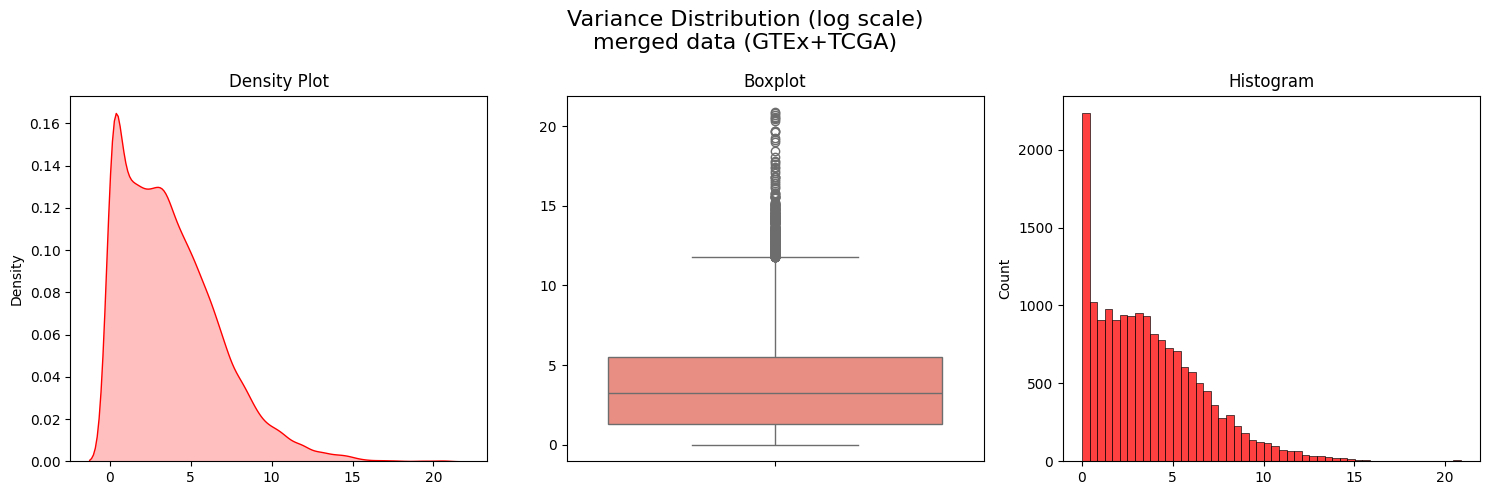

Порог отсечения (нижний 1%): 0.001430
Осталось генов: 17218 из 17392


In [56]:
# 1. Рассчитываем порог только для нижней границы
p01 = vars.quantile(0.01)

# 2. Фильтруем: оставляем всё, что строго больше этого порога
# Весь "верх" (высокая вариабельность) сохраняется полностью
high_var = vars[vars > p01]

# 3. Рисуем результат
# Теперь на графиках будет видна только значимая вариабельность
plot_var(high_var, save_path='/mnt/jack-5/amismailov/miRNA_study/figures/log_varience_mrna_merged_filtered.jpg')

print(f"Порог отсечения (нижний 1%): {p01:.6f}")
print(f"Осталось генов: {len(high_var)} из {len(vars)}")

In [58]:
high_var.index

Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084',
       'ENSG00000001167',
       ...
       'ENSG00000285976', 'ENSG00000286095', 'ENSG00000286190',
       'ENSG00000286219', 'ENSG00000286224', 'ENSG00000286264',
       'ENSG00000286522', 'ENSG00000286920', 'ENSG00000287080',
       'ENSG00000287585'],
      dtype='object', length=17218)

In [60]:
df_merged_sub=df_merged_sub.loc[high_var.index]
df_merged_sub.shape

(17218, 35580)

In [62]:
df_merged_sub

,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,f6c215ea-5381-4521-bb61-be8e97,f9d6fb1b-988e-4d28-9272-cc672f,faadb553-9437-42cb-b469-498d67,fbb41c94-aabd-49cc-90b2-882c3e,fc0aa1e4-c1d8-43ed-a5cd-038f61,fd4edc52-09ef-4b01-be7c-f23f05,fe4b3b1c-9f7f-4109-8a76-ca1d6f,fe591474-99d7-44d3-be73-c3b8ed,fe83e13f-9754-403b-8f74-d6caf8,ffc76bfb-61f6-4492-a782-c23321
ENSG00000000003,24.483706,20.911614,19.497767,17.091550,18.257684,22.377526,24.959735,22.870446,31.910213,21.520535,...,30.585676,35.348625,37.658157,28.782489,8.978696,10.949873,212.498873,11.932543,65.229204,15.971903
ENSG00000000005,6.912864,7.426833,12.968614,0.948350,68.064882,6.710334,12.168769,13.119936,11.317563,6.706862,...,1.552510,0.388546,0.158933,0.024295,0.028189,0.189491,2.676623,0.000000,0.299973,0.882351
ENSG00000000419,4.937467,4.826987,6.300498,3.478406,7.898260,4.942264,7.589236,7.210019,5.671506,7.482194,...,13.056098,5.352934,10.574750,9.114176,8.623198,7.915481,26.815117,18.326418,30.944793,30.847607
ENSG00000000457,2.261751,1.972197,1.951711,0.842236,2.391279,1.274841,1.870172,3.239976,1.864570,2.545027,...,3.062372,1.643973,5.401579,2.219777,3.453437,1.725366,2.105817,3.562212,2.819844,5.628781
ENSG00000000460,0.177457,0.177047,0.138742,0.070957,0.190778,0.102294,0.149611,0.296607,0.199455,0.241967,...,0.579031,0.245968,0.779936,0.266608,0.425892,0.204041,0.387967,0.411022,0.712466,0.503083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.771119,1.590254,1.549935,0.615173,1.979411,0.905882,2.646323,3.180615,1.324111,1.978584,...,0.332170,0.122045,0.782107,0.836881,0.485514,0.994653,0.364193,0.302573,0.492056,0.675430
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.493704,0.483721,4.649788,1.066163,0.824709,0.000000,1.443470,3.148000,12.871635,2.294613
ENSG00000286920,0.031883,0.000000,0.062483,0.000000,0.020862,0.000000,0.000000,0.000000,0.000000,0.022628,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.370791,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.977795,0.000000,0.867132,0.777200,0.000000,2.364239,0.615171,1.809486


In [63]:
import numpy as np
import pandas as pd

# Предположим, df_merged: гены в строках, образцы в столбцах
# Нам нужна корреляция между генами (строками)
data_v = df_merged_sub.values 

# Вычисляем матрицу корреляции
# rowvar=True означает, что каждая строка — это переменная (ген)
corr_matrix = np.corrcoef(data_v, rowvar=True)

# Оборачиваем обратно в DataFrame только если это необходимо
# corr_df = pd.DataFrame(corr_matrix, index=df_merged.index, columns=df_merged.index)

In [65]:
# 1. Берем только верхний треугольник матрицы (без диагонали)
upper = np.triu(corr_matrix, k=1)

# 2. Находим индексы генов, где корреляция > 0.9 (например)
to_drop_idx = np.where(np.any(np.abs(upper) > 0.9, axis=0))[0]

# 3. Получаем имена генов для удаления
genes_to_drop = df_merged_sub.index[to_drop_idx]

In [66]:
len(genes_to_drop)

838

In [67]:
df_merged_sub = df_merged_sub.drop(genes_to_drop)

print(f"Удалено генов: {len(genes_to_drop)}")

print(f"Генов теперь: {df_merged_sub.shape[0]}")

Удалено генов: 838
Генов теперь: 16380


In [68]:
df_merged_sub.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_sub_v2.parquet')

In [1]:
import pandas as pd 
df_merged_sub = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_sub_v2.parquet')

In [4]:
with open("/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/shared_features_v2.txt", "w", encoding="utf-8") as f:
    for line in df_merged_sub.index.tolist():
        f.write(line + "\n")
